In [1]:
import pandas as pd 
import seaborn as sns 

study_hours_per_day
exam_score



## Separando dados de entrada com os dados que queremos descobrir 

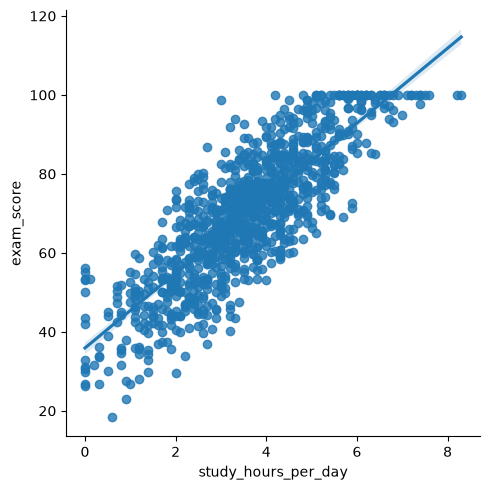

In [6]:
df = pd.read_csv(r".\data\dados_tratados.csv")
sns.lmplot(data=df, x="study_hours_per_day" ,y="exam_score");

**EXERCICÍOS**

## Seleção de variáveis para o modelo:

Este trecho define as variáveis preditoras (`X`) e a variável alvo (`y`) que serão usadas no treinamento do modelo de regressão.

### Variáveis preditoras (X)
- **study_hours_per_day**: horas de estudo por dia
- **social_media_hours**: horas em redes sociais
- **netflix_hours**: horas assistindo Netflix
- **exercise_frequency**: frequência de exercícios físicos

### Variável alvo (y)
- **exam_score**: nota do exame — é o que o modelo tentará prever com base nas variáveis acima.

### Observação
Todas as colunas selecionadas em `X` já são numéricas, então este trecho **não deve gerar o erro de conversão de string para float** que apareceu antes (relacionado à coluna de escolaridade). Se o erro `could not convert string to float: 'Master'` persistir, é sinal de que em algum outro ponto do código o `X` original (com todas as colunas do `df`) ainda está sendo usado no `fit()`, em vez deste `X` filtrado.

In [92]:
X = df[["study_hours_per_day","social_media_hours","netflix_hours","exercise_frequency"]]
y = df["exam_score"]


## Treinamento do modelo de regressão linear 
Este trecho cria e treina um modelo de **Regressão Linear** usando o scikit-learn.

## O que o código faz
1. Importa a classe `LinearRegression` do módulo `sklearn.linear_model`.
2. Instancia o modelo: `modelo = LinearRegression()`.
3. Treina o modelo com `modelo.fit(X, y)`, onde:
   - **X**: variáveis preditoras (ex: `study_hours_per_day`, `social_media_hours`, `netflix_hours`, `exercise_frequency`)
   - **y**: variável alvo (`exam_score`)

In [93]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()
modelo.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 9.54,-2.53,-2.24, 1.47]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['study_hours_per_day','social_media_hours','netflix_hours', 'exercise_frequency']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,41.67
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


## Criando um novo registro para previsão

Este trecho cria um novo DataFrame, `novo_aluno`, representando um único aluno hipotético com valores específicos para cada variável preditora usada no modelo.

### Valores definidos
- **study_hours_per_day**: 5 horas de estudo por dia
- **social_media_hours**: 5 horas em redes sociais
- **netflix_hours**: 5 horas assistindo Netflix
- **exercise_frequency**: 5 (frequência de exercícios)

### Por que isso é necessário
Para usar `modelo.predict()`, é preciso passar os dados no **mesmo formato** (mesmas colunas, mesma ordem, mesmo tipo) usado no treinamento (`X`). Criar um DataFrame com essas colunas, em vez de passar uma lista simples, garante que o scikit-learn reconheça corretamente qual valor corresponde a qual variável.

### Próximo passo
Com esse DataFrame pronto, a previsão pode ser feita assim:
```python
previsao = modelo.predict(novo_aluno)
print(previsao)
```
Isso retorna a nota de exame (`exam_score`) que o modelo prevê para esse aluno hipotético.

In [94]:
novo_aluno = pd.DataFrame({"study_hours_per_day":[5],
               "social_media_hours":[5],
               "netflix_hours":[5],
               "exercise_frequency":[5],
               })


## Fazendo a previsão e exibindo o resultado
- Este trecho usa o modelo treinado para prever a nota do exame do aluno hipotético e exibe o resultado.

### O que o código faz
1. `modelo.predict(novo_aluno)`: gera a previsão de `exam_score` com base nos valores definidos em `novo_aluno`.
2. `previsao`: guarda o resultado dessa previsão.
3. `print(previsao)`: exibe o valor na tela.

### Formato do resultado
O `predict()` sempre retorna um **array**, mesmo para uma única previsão. Então o `print` vai mostrar algo como:

In [99]:
previsao = modelo.predict(novo_aluno)
print(previsao)

[72.87848211]


## Coeficiente angular do modelo

Este trecho extrai e exibe os coeficientes angulares (pesos) do modelo de regressão linear treinado.

### O que o código faz
- `modelo.coef_`: retorna um array com um coeficiente para cada variável preditora usada em `X`, na mesma ordem em que as colunas foram passadas no treinamento.
- `angular`: guarda esse array.
- `print(angular)`: exibe os coeficientes na tela.


In [ ]:
#Coeficiente angular 

angular = modelo.coef_
print(angular)

[ 9.53821602 -2.52567637 -2.24287832  1.47132193]


## Coeficiente linear do modelo

Este trecho extrai o **coeficiente linear** (intercepto) do modelo de regressão linear treinado.

### O que o código faz
- `modelo.intercept_`: retorna o valor do intercepto — a previsão de `exam_score` quando todas as variáveis preditoras (`study_hours_per_day`, `social_media_hours`, `netflix_hours`, `exercise_frequency`) são iguais a zero.

### Como interpretar
O intercepto é o ponto de partida da reta de regressão. Ele representa a nota base prevista pelo modelo antes de considerar o efeito de qualquer variável — na prática, um valor de referência que se soma (ou subtrai) aos efeitos dos coeficientes angulares para chegar na previsão final.


In [97]:
#Coeficiente linear 
modelo.intercept_


np.float64(41.67356582825143)

## Avaliando o desempenho do modelo (R²)

Este trecho calcula o **coeficiente de determinação (R²)** do modelo, usando os próprios dados de treinamento (`X` e `y`).

### O que o código faz
- `modelo.score(X, y)`: calcula o R² comparando as previsões do modelo com os valores reais de `y`.

### Como interpretar o R²
- Varia de 0 a 1 (pode ser negativo em casos raros de modelo muito ruim).
- Indica a proporção da variação de `exam_score` que é explicada pelas variáveis usadas no modelo.
- Exemplo: um R² de `0.85` significa que 85% da variação nas notas é explicada pelas variáveis preditoras (`study_hours_per_day`, `social_media_hours`, `netflix_hours`, `exercise_frequency`).
- Quanto mais próximo de 1, melhor o ajuste do modelo aos dados.

In [98]:
modelo.score(X,y)

0.7667716432987342